# Validación de pesos

Notebook con todas las importaciones necesarias para ejecutar los modelos de:

- `NeuralProphet_Demanda.ipynb`
- `RNN_Demanda.ipynb`
- `SARIMA.ipynb`
- `XGBoost_demanda_corregido.ipynb`

Las importaciones se agrupan por tema y están deduplicadas respecto a lo usado en cada notebook original.

In [1]:
# Reproducibilidad (NeuralProphet_Demanda.ipynb, RNN_Demanda.ipynb)
import os
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import random
random.seed(42)

import numpy as np
np.random.seed(42)

import torch
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import tensorflow as tf
tf.random.set_seed(42)

# Procesamiento general (todos los notebooks)
import json
import time
import itertools
import re
import pandas as pd
import holidays

# Machine learning, procesamiento (sklearn / sktime)
from sklearn.model_selection import (
    TimeSeriesSplit,
    train_test_split,
    GridSearchCV,
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError

# Modelos específicos

# NeuralProphet_Demanda.ipynb
from neuralprophet import NeuralProphet, set_log_level

# RNN_Demanda.ipynb
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.layers import Dropout

# XGBoost_demanda_corregido.ipynb
import xgboost

# SARIMA.ipynb
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# Análisis de series de tiempo
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, acf, pacf
from scipy.signal import periodogram, welch

# Optimización de hiperparámetros
import optuna
import optuna.visualization as vis
from optuna.samplers import TPESampler

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Warnings
import warnings
warnings.filterwarnings("ignore")

c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


## Mejores hiperparámetros por modelo

Se leen los CSV de `data/best_train_models` (cada uno ya viene ordenado de menor a mayor `mape_mean`) y se descartan las columnas de métricas de error (`mape_mean`, `mae_mean`, `rmse_mean`, `smape_mean`) y el índice de `trial`, quedando solo los hiperparámetros del mejor modelo encontrado por Optuna. Para XGBoost se usa la versión `v2` (`best_models_xgboost_v2.csv`).

In [2]:
metric_cols = ["mape_mean", "mae_mean", "rmse_mean", "smape_mean"]


def load_best_params(path, drop_cols=("trial", *metric_cols)):
    df = pd.read_csv(path, index_col=0)
    best_row = df.sort_values("mape_mean").iloc[0]
    params = best_row.drop(labels=[c for c in drop_cols if c in best_row.index]).to_dict()
    # columnas enteras (n_lags, epochs, units, etc.) llegan como float al mezclarse
    # con columnas decimales en la fila; se devuelven como int cuando el valor es entero
    return {
        k: int(v) if isinstance(v, float) and v.is_integer() else v
        for k, v in params.items()
    }


best_params_neuralprophet = load_best_params(
    "../../../data/best_train_models/best_models_NeuralProphet.csv"
)
best_params_rnn = load_best_params(
    "../../../data/best_train_models/best_models_rnn.csv"
)
best_params_xgboost = load_best_params(
    "../../../data/best_train_models/best_models_xgboost_v2.csv"
)

dict_params= {
    "NeuralProphet": best_params_neuralprophet, 
    "RNN": best_params_rnn, 
    "XGBoost": best_params_xgboost
}
dict_params

{'NeuralProphet': {'n_lags': 3,
  'n_changepoints': 11,
  'learning_rate': 0.0096563538985294,
  'epochs': 89,
  'batch_size': 32},
 'RNN': {'input_timesteps': 52,
  'units': 96,
  'lr': 0.0011178917527043,
  'epochs': 120,
  'dropout_rate': 0.033268680966822,
  'recurrent_dropput_rate': 0.1041403772456473},
 'XGBoost': {'n_estimators': 226,
  'max_depth': 8,
  'learning_rate': 0.01854,
  'min_child_weight': 14.30323,
  'gamma': 0.77908,
  'reg_lambda': 1.89223,
  'reg_alpha': 4.78704,
  'subsample': 0.74829,
  'colsample_bytree': 0.62499}}

Se cargan todos los datos requeridos 

In [3]:
# se cargan los pesos 
with open("../../../data/best_train_models/ensemble_weights_frozen.json", "r") as f:
    ensemble_weights = json.load(f)

ensemble_weights


{'neuralprophet_preds': 0.24506088621944577,
 'rnn_preds': 0.26792988268963663,
 'xgboost_preds_v2': 0.2898471373861941,
 'SARIMA_preds': 0.19716209370472365}

In [4]:
# se importan todos los datos requeridos - serie original
date_close =  pd.read_csv("../../../data/csv/EC_GER_Weekly.csv")
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
df_data_close["Start date"] = pd.to_datetime(df_data_close["Start date"])
df_data_close = df_data_close.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
#df_data_close = df_data_close.rename(columns={
#    "Start date": "Date",
#    "value": "original"
#})

df_data_close.head()

,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


Se traen nuevos datos - serie de validación (desde el 02-ene-2026 hasta el 03-ago-2026) agrupados de forma semanal al igual que el primer dataset

In [5]:

date_close_val =  pd.read_csv("../../../data/csv/EC_GER_val_Weekly.csv")
df_data_close_val = pd.DataFrame(date_close_val.copy()) # copia del df de precios de cierre como df
df_data_close_val["Start date"] = pd.to_datetime(df_data_close_val["Start date"])
df_data_close_val = df_data_close_val.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
#df_data_close_val = df_data_close_val.rename(columns={
#    "Start date": "Date",
#    "value": "original"
#})

df_data_close_val.head()

,Start date,value
0,2026-01-05,1.344450e+06
1,2026-01-12,1.533895e+06
2,2026-01-19,1.474633e+06
3,2026-01-26,1.543555e+06
4,2026-02-02,1.545466e+06


In [6]:
# se grafican los datos de consumo de forma semanal (entrenamiento y validación)

# se concatenan ambos dataframes en la gráfica
df_plot = pd.concat([
    df_data_close.assign(Serie="Entrenamiento"),
    df_data_close_val.assign(Serie="Validación"),
], ignore_index=True)

fig = px.line(
    df_plot, # dataframe combinado con columna "Serie" para distinguir cada tramo
    x="Start date",
    y="value",
    color="Serie",
    color_discrete_map={
        "Entrenamiento": "black",
        "Validación": "orange",
    },
    labels={ # etiquetas para los ejes
        "Date": "Fecha",
        "original": "Consumo",
        "Serie": ""
    },
    template="plotly_white" #estilos
)

fig.update_traces(
    line=dict(width=2),
    showlegend=True
)

#margenes y medidas de la gráfica
fig.update_layout(
    width=1200,
    height=600,
    legend_title_text="",
    margin=dict(l=60, r=30, t=30, b=60),
    plot_bgcolor="white",
    paper_bgcolor="white"
)
# eje horizontal y malla
fig.update_xaxes(
    tickformat="%Y-%m-%d",
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=1,
    automargin=True
)
# eje vertical y malla
fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=1,
    automargin=True
)

fig.add_vline(
    x=df_data_close_val["Start date"].min(),
    line=dict(color="black", dash="dash", width=1)
)

fig.show()

Ahora se entrenan todos los modelos y se generan las predicciones sobre el nuevo conjunto. Para el entrenamiento, se toman los parámetros obtenidos en el proceso de optmización y se entrenan sobre todo el dataset original

In [7]:
# fecha que se usará para partir el conjunto de validación final 
fecha_data_val = df_data_close_val["Start date"].iloc[0]
print(f"fecha data/val: {fecha_data_val}")

# ahora se une todo el dataset para poder calcular las variables en xgboost
# la fecha 2026-01-05 aparece en ambos CSV (última fila de df_data_close y primera de
# df_data_close_val, con valores distintos); se descarta esa fila duplicada del set de
# validación para no contarla dos veces en train
df_data_set_full = pd.concat([
    df_data_close.assign(Serie="Entrenamiento"),
    df_data_close_val[
        df_data_close_val["Start date"] > df_data_close["Start date"].max()
    ].assign(Serie="Validación"),
], ignore_index=True)

fecha data/val: 2026-01-05 00:00:00


# Modelo XGBoost
se traen todas las funciones requeridas para el procesamiento de la información, se entrena el modelo y se generan las predicciones sobre el conjunto de validación 

In [8]:
# función para obtener los valores de las variables año, mes y trimestre
def get_data_times(df, columnName):
    df_copy = df.copy()
    df_copy["year"] = df_copy[columnName].dt.year
    df_copy["month"] = df_copy[columnName].dt.month
    df_copy["quarter"] = df_copy[columnName].dt.quarter

    return df_copy


df_features = get_data_times(
    df_data_set_full,
    columnName="Start date"
)

# función para obtener los lags a partir de la columna start date
def make_df_full_lags(df, lags, variables):
    df_copy = df.copy()

    for variable in variables:
        for lag in lags:
            df_copy[f"{variable}_lag_{lag}"] = (
                df_copy[variable].shift(lag)
            )

    return df_copy


variables = ["value"]

lags = [1, 2, 3, 4, 8, 12, 52]

df_features = make_df_full_lags(
    df_features,
    lags=lags,
    variables=variables
)

# medias móviles de los precios de cierre: se crea una función para que tome las medias móviles de determinados
# días. Se toman estas medias moviles para los precios anteriores
def make_df_full_averages(
    df,
    vars_list,
    ma_periods,
    dropna=False,
    overwrite=False
):
    df_copy = df.copy()

    # solo se permiten las variables originales (sin _lag_ ni _ma_)
    clean_vars = [
        v for v in vars_list
        if v in df_copy.columns
        and "_lag_" not in v
        and "_ma_" not in v
    ]

    missing = [
        v for v in vars_list
        if v not in df_copy.columns # valida si las variables requeridas existen
    ]

    if missing:
        raise ValueError(
            f"Estas columnas no existen: {missing}"
        )

    for variable in clean_vars:
        for period in ma_periods:

            name = f"{variable}_ma_{period}" # nombre de columna para cálculo de MA de variable

            if (name in df_copy.columns) and (not overwrite):
                continue

            df_copy[name] = (
                df_copy[variable]
                .shift(1) # evita leakage, dado que se toma desde la posición t-1 hacia atras
                .rolling(window=period)
                .mean()
            )

    if dropna:
        df_copy = df_copy.dropna().reset_index(drop=True)

    return df_copy

ma_periods = [
    2, # dos semanas desde la anterior
    3, # tres semanas desde la anterior
    4, # 4 semanas desde la anterior (desde la ultima semana, un mes)
    8, # 8 semanas desde la anterior (desde la ultima semana, dos meses)
    12, # 12 semanas desde la anterior (desde la ultima semana, tres meses)
    16 # 16 semanas desde la anterior (desde la última semana, 4 meses)
]
df_features = make_df_full_averages(
    df_features,
    vars_list=variables,
    ma_periods=ma_periods,
    dropna=False
)

In [9]:
df_features

,Start date,value,Serie,year,month,quarter,value_lag_1,value_lag_2,value_lag_3,value_lag_4,value_lag_8,value_lag_12,value_lag_52,value_ma_2,value_ma_3,value_ma_4,value_ma_8,value_ma_12,value_ma_16
0,2015-01-05,1.240580e+06,Entrenamiento,2015,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-12,1.465239e+06,Entrenamiento,2015,1,1,1.240580e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-19,1.479857e+06,Entrenamiento,2015,1,1,1.465239e+06,1.240580e+06,NaN,NaN,NaN,NaN,NaN,1.352910e+06,NaN,NaN,NaN,NaN,NaN
3,2015-01-26,1.516270e+06,Entrenamiento,2015,1,1,1.479857e+06,1.465239e+06,1.240580e+06,NaN,NaN,NaN,NaN,1.472548e+06,1.395226e+06,NaN,NaN,NaN,NaN
4,2015-02-02,1.507588e+06,Entrenamiento,2015,2,1,1.516270e+06,1.479857e+06,1.465239e+06,1.240580e+06,NaN,NaN,NaN,1.498064e+06,1.487122e+06,1.425487e+06,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601,2026-07-13,1.216919e+06,Validación,2026,7,3,1.216261e+06,1.255063e+06,1.197294e+06,1.209717e+06,1.145060e+06,1.240591e+06,1.188129e+06,1.235662e+06,1.222873e+06,1.219584e+06,1.184308e+06,1.190560e+06,1.211025e+06
602,2026-07-20,1.234010e+06,Validación,2026,7,3,1.216919e+06,1.216261e+06,1.255063e+06,1.197294e+06,1.133889e+06,1.217128e+06,1.170252e+06,1.216590e+06,1.229415e+06,1.221384e+06,1.193290e+06,1.188588e+06,1.207230e+06
603,2026-07-27,1.191925e+06,Validación,2026,7,3,1.234010e+06,1.216919e+06,1.216261e+06,1.255063e+06,1.166683e+06,1.145303e+06,1.169594e+06,1.225465e+06,1.222397e+06,1.230563e+06,1.205805e+06,1.189994e+06,1.200169e+06
604,2026-08-03,1.204935e+06,Validación,2026,8,3,1.191925e+06,1.234010e+06,1.216919e+06,1.216261e+06,1.150494e+06,1.209238e+06,1.153106e+06,1.212968e+06,1.214285e+06,1.214779e+06,1.208961e+06,1.193880e+06,1.198855e+06


In [10]:
# conjuntos train/test
train = df_features[
    df_features["Start date"] <= fecha_data_val
].copy()

test = df_features[
    df_features["Start date"] > fecha_data_val
].copy()

In [11]:
print("=== serie original XGBOOST ===")
print("Cantidad:", len(df_data_close))
print("Inicio:", df_data_close["Start date"].min())
print("Fin:", df_data_close["Start date"].max())


print("\n=== TRAIN XGBOOST ===")
print("Cantidad:", len(train))
print("Inicio:", train["Start date"].min())
print("Fin:", train["Start date"].max())

print("\n=== TEST XGBOOST ===")
print("Cantidad:", len(test))
print("Inicio:", test["Start date"].min())
print("Fin:", test["Start date"].max())

=== serie original XGBOOST ===
Cantidad: 575
Inicio: 2015-01-05 00:00:00
Fin: 2026-01-05 00:00:00

=== TRAIN XGBOOST ===
Cantidad: 575
Inicio: 2015-01-05 00:00:00
Fin: 2026-01-05 00:00:00

=== TEST XGBOOST ===
Cantidad: 31
Inicio: 2026-01-12 00:00:00
Fin: 2026-08-10 00:00:00


Se esquematizan los datos como un problema de aprendizaje supervisado: X es el array de features, y es el array de valores (columna value, que es la que se quiere predecir)

In [12]:
target = "value"

features = [
    col for col in df_features.columns
    if col not in ["value", "Start date", "Serie"]
]

X_folds = (
    train
    .set_index("Start date")[features]
    .copy()
)

y_folds = (
    train
    .set_index("Start date")[target]
    .copy()
)

X_val = (
    test
    .set_index("Start date")[features]
    .copy()
)

y_val = (
    test
    .set_index("Start date")[target]
    .copy()
)

In [13]:
# dimensiones de los datasets de entrenamiento y prueba
print("X TrainG:", X_folds.shape)
print("y TrainG:", y_folds.shape)

print("X TestF:", X_val.shape)
print("y TestF:", y_val.shape)

X TrainG: (575, 16)
y TrainG: (575,)
X TestF: (31, 16)
y TestF: (31,)


In [14]:
# funcion para instanciar el modelo 
# función de creación del modelo 
def build_xgboost_regressor(**params):
    # puedes establecer valores por defecto si faltan
    params.setdefault("objective", "reg:squarederror")
    params.setdefault("tree_method", "exact")
    params.setdefault("random_state", 42)

    model = xgboost.XGBRegressor(**params)
    return model
best_params_xgboost

{'n_estimators': 226,
 'max_depth': 8,
 'learning_rate': 0.01854,
 'min_child_weight': 14.30323,
 'gamma': 0.77908,
 'reg_lambda': 1.89223,
 'reg_alpha': 4.78704,
 'subsample': 0.74829,
 'colsample_bytree': 0.62499}

In [15]:
# ahora se intancia el modelo con los parametros obtenidos del train
model_xgboost = build_xgboost_regressor(
    **best_params_xgboost
)

In [16]:
model_xgboost.fit(X_folds, y_folds)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.62499, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.77908, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01854, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=14.30323, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=226,
             n_jobs=None, num_parallel_tree=None, ...)

In [17]:
y_pred = model_xgboost.predict(X_val)
# metricas de error 

mape_val_xgboost = mean_absolute_percentage_error(y_val, y_pred)
mae_val_xgboost  = mean_absolute_error(y_val, y_pred)
rmse_val_xgboost = np.sqrt(mean_squared_error(y_val, y_pred))
smape_calc_val = MeanAbsolutePercentageError(symmetric=True) 
smape_val_xgboost = smape_calc_val(y_val, y_pred)

print(f"mape validación: {mape_val_xgboost*100:.4f}%")
print(f"mae validación: {mae_val_xgboost}")
print(f"rmse validación: {rmse_val_xgboost}")
print(f"smape validación: {smape_val_xgboost*100:.4f}")

mape validación: 2.9031%
mae validación: 38236.75458525353
rmse validación: 48904.59010605635
smape validación: 2.9173


In [18]:
# renombramiento para identificar las predicciones del xgboost
y_preds_xgboost = y_pred


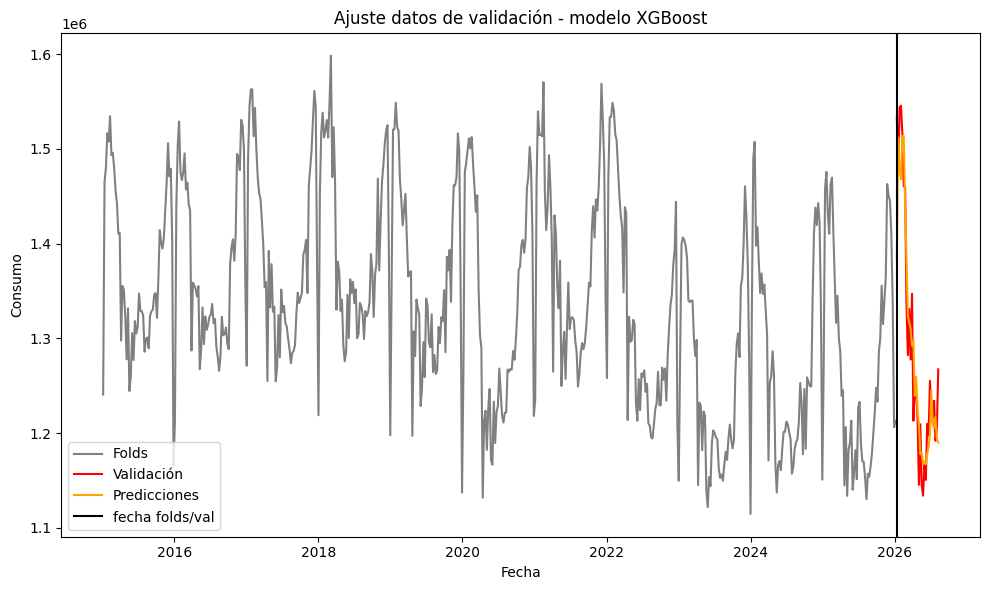

In [19]:
# ajute visual 
plt.figure(figsize=(10,6))
plt.plot(X_folds.index, y_folds , label="Folds", color="gray")
plt.plot(X_val.index, y_val, label="Validación", color="red")
plt.plot(X_val.index[-len(y_preds_xgboost):], y_preds_xgboost, label="Predicciones", color="orange")
plt.axvline(X_val.index[0], label="fecha folds/val", color="black")
plt.title("Ajuste datos de validación - modelo XGBoost")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
#plt.grid(True)
plt.legend()
plt.tight_layout()

# Modelo RNN
Análogo al xgboost, se traen todas las funciones requeridas para el procesamiento de la información, se entrena el modelo y se generan las predicciones sobre el conjunto de validación 

In [20]:
# seleccion de variables para el RNN - se muestran todas las variables (excepto "Serie",
# que es texto y rompería el tensor de entrada), se usan nombres propios (features_rnn,
# target_rnn) para no sobrescribir las variables ya usadas por XGBoost
target_rnn = ["value"]
features_rnn = [
    col for col in df_features.columns
    if col not in ("Start date", "value", "Serie")
]
features_rnn

['year',
 'month',
 'quarter',
 'value_lag_1',
 'value_lag_2',
 'value_lag_3',
 'value_lag_4',
 'value_lag_8',
 'value_lag_12',
 'value_lag_52',
 'value_ma_2',
 'value_ma_3',
 'value_ma_4',
 'value_ma_8',
 'value_ma_12',
 'value_ma_16']

In [21]:
df_features.head()

,Start date,value,Serie,year,month,quarter,value_lag_1,value_lag_2,value_lag_3,value_lag_4,value_lag_8,value_lag_12,value_lag_52,value_ma_2,value_ma_3,value_ma_4,value_ma_8,value_ma_12,value_ma_16
0,2015-01-05,1.240580e+06,Entrenamiento,2015,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-12,1.465239e+06,Entrenamiento,2015,1,1,1.240580e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-19,1.479857e+06,Entrenamiento,2015,1,1,1.465239e+06,1.240580e+06,NaN,NaN,NaN,NaN,NaN,1.352910e+06,NaN,NaN,NaN,NaN,NaN
3,2015-01-26,1.516270e+06,Entrenamiento,2015,1,1,1.479857e+06,1.465239e+06,1.240580e+06,NaN,NaN,NaN,NaN,1.472548e+06,1.395226e+06,NaN,NaN,NaN,NaN
4,2015-02-02,1.507588e+06,Entrenamiento,2015,2,1,1.516270e+06,1.479857e+06,1.465239e+06,1240580.1,NaN,NaN,NaN,1.498064e+06,1.487122e+06,1.425487e+06,NaN,NaN,NaN


In [22]:
def create_dataset(data, target_array, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i : (i + time_step), :])
        y.append(target_array[i + time_step])
    return np.array(X), np.array(y)

In [23]:
# se descartan las filas con NaN (las primeras semanas no tienen suficiente historia,
# p. ej. value_lag_52 necesita 52 semanas previas); ninguna fila del conjunto de
# validación real se pierde en este paso porque ya tienen toda la historia disponible
df_features_rnn = df_features.dropna().reset_index(drop=True)

train_rnn = df_features_rnn[
    df_features_rnn["Start date"] <= fecha_data_val
].reset_index(drop=True)

val_rnn = df_features_rnn[
    df_features_rnn["Start date"] > fecha_data_val
].reset_index(drop=True)

print("len train_rnn:", len(train_rnn))
print("len val_rnn:", len(val_rnn))

len train_rnn: 523
len val_rnn: 31


In [24]:
L_rnn = best_params_rnn["input_timesteps"]

X_train_rnn, y_train_rnn = create_dataset(
    train_rnn[features_rnn].values,
    train_rnn[target_rnn].values.ravel(),
    L_rnn
)

# se antepone la cola de train (ultimos L_rnn registros) al conjunto de validación para
# que la primera ventana de val tenga contexto histórico, y para que el número de
# secuencias de salida sea igual a len(val_rnn) sin importar L_rnn — así el conjunto de
# validación final queda con la misma longitud en todos los modelos (XGBoost: len(test))
combined_rnn = pd.concat(
    [train_rnn.tail(L_rnn), val_rnn],
    axis=0
).reset_index(drop=True)

X_val_rnn, y_val_rnn = create_dataset(
    combined_rnn[features_rnn].values,
    combined_rnn[target_rnn].values.ravel(),
    L_rnn
)

print("len val_rnn:", len(val_rnn))
print("len y_val_rnn (secuencias RNN):", len(y_val_rnn))
print("len test (XGBoost):", len(test))

len val_rnn: 31
len y_val_rnn (secuencias RNN): 31
len test (XGBoost): 31


In [25]:
scaler_X_rnn = MinMaxScaler()
scaler_y_rnn = MinMaxScaler()

n_features_rnn = X_train_rnn.shape[-1]

X_train_rnn_scaled = scaler_X_rnn.fit_transform(
    X_train_rnn.reshape(-1, n_features_rnn)
).reshape(X_train_rnn.shape)

X_val_rnn_scaled = scaler_X_rnn.transform(
    X_val_rnn.reshape(-1, n_features_rnn)
).reshape(X_val_rnn.shape)

y_train_rnn_scaled = scaler_y_rnn.fit_transform(y_train_rnn.reshape(-1, 1))

In [26]:
# input_timesteps: numero de rezagos
# n_features: numero de caracteristicas (variables exogenas + variable objetivo)
# units: numero de unidades de la capa recurrente
# lr: tasa de aprendizaje
def build_rnn(input_timesteps, n_features, units, lr, dropout_rate=0.2, recurrent_dropout_rate=0.1):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_timesteps, n_features)))
    model.add(layers.SimpleRNN(
        units=units,
        activation="tanh",
        stateful=False,
        dropout=dropout_rate,
        recurrent_dropout=recurrent_dropout_rate
    ))
    model.add(layers.Dense(units=1, activation="linear"))
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="mean_squared_error"
    )
    return model

In [27]:
best_params_rnn

{'input_timesteps': 52,
 'units': 96,
 'lr': 0.0011178917527043,
 'epochs': 120,
 'dropout_rate': 0.033268680966822,
 'recurrent_dropput_rate': 0.1041403772456473}

In [28]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model_rnn = build_rnn(
    L_rnn,
    n_features_rnn,
    best_params_rnn["units"],
    best_params_rnn["lr"],
    dropout_rate=best_params_rnn["dropout_rate"],
    recurrent_dropout_rate=best_params_rnn["recurrent_dropput_rate"]
)

early_stop_rnn = callbacks.EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

model_rnn.fit(
    X_train_rnn_scaled,
    y_train_rnn_scaled,
    epochs=best_params_rnn["epochs"],
    #batch_size=best_params_rnn["batch_size"],
    shuffle=False,
    verbose=1,
    callbacks=[early_stop_rnn]
)


Epoch 1/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1799
Epoch 2/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0636
Epoch 3/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0514
Epoch 4/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0424
Epoch 5/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0502
Epoch 6/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0523
Epoch 7/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0385
Epoch 8/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0358
Epoch 9/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0342
Epoch 10/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0298
Epoch 11/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0310
Epoch 12/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0275
Epoch 13/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0261
Epoch 14/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0254
Epoch 15/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - l

In [29]:
y_pred_scaled_rnn = model_rnn.predict(X_val_rnn_scaled)
y_pred_rnn = scaler_y_rnn.inverse_transform(y_pred_scaled_rnn)
y_true_rnn = y_val_rnn.reshape(-1, 1)

smape_calc_rnn = MeanAbsolutePercentageError(symmetric=True)
mape_rnn = mean_absolute_percentage_error(y_true_rnn, y_pred_rnn)
mae_rnn = mean_absolute_error(y_true_rnn, y_pred_rnn)
rmse_rnn = np.sqrt(mean_squared_error(y_true_rnn, y_pred_rnn))
smape_rnn = smape_calc_rnn(y_true_rnn, y_pred_rnn)

print(f"mape validación: {mape_rnn*100:.4f}%")
print(f"mae validación: {mae_rnn}")
print(f"rmse validación: {rmse_rnn}")
print(f"smape validación: {smape_rnn*100:.4f}")

# se verifica que el conjunto de validación final tenga la misma longitud en RNN y XGBoost
print(f"\nlongitud validación RNN: {len(y_pred_rnn)}")
print(f"longitud validación XGBoost: {len(test)}")
assert len(y_pred_rnn) == len(test), "el conjunto de validación de RNN no coincide en longitud con el de XGBoost"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
mape validación: 4.0381%
mae validación: 53911.88827188942
rmse validación: 70140.15515055899
smape validación: 4.1461

longitud validación RNN: 31
longitud validación XGBoost: 31


In [30]:
y_preds_recurrent = y_pred_rnn.ravel()

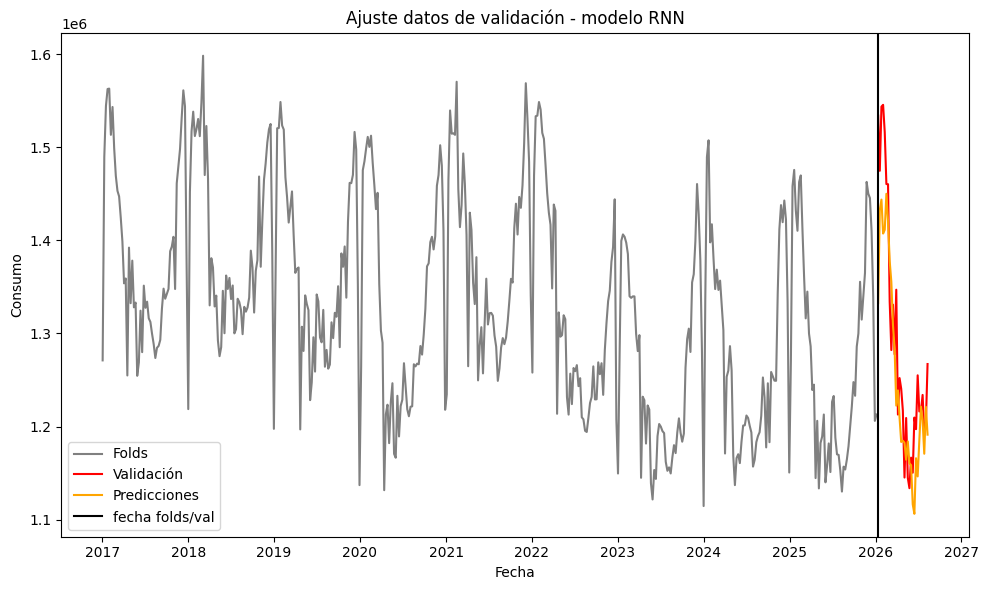

In [31]:
# ajuste visual - RNN
dates_train_rnn = train_rnn["Start date"].values[L_rnn:]
dates_val_rnn = val_rnn["Start date"].values

plt.figure(figsize=(10,6))
plt.plot(dates_train_rnn, y_train_rnn, label="Folds", color="gray")
plt.plot(dates_val_rnn, y_val_rnn, label="Validación", color="red")
plt.plot(dates_val_rnn, y_pred_rnn.ravel(), label="Predicciones", color="orange")
plt.axvline(dates_val_rnn[0], label="fecha folds/val", color="black")
plt.title("Ajuste datos de validación - modelo RNN")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
#plt.grid(True)
plt.legend()
plt.tight_layout()

# Modelo NeuralProphet
Análogo a los demás, se traen todas las funciones requeridas para el procesamiento de la información, se entrena el modelo y se generan las predicciones sobre el conjunto de validación 

In [32]:
df_data_set_full_np = df_data_set_full.copy()
df_data_set_full_np = df_data_set_full_np[["Start date", "value"]]
df_data_set_full_np.head()

,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


In [33]:
# renombramiento de columnas 
df_data_set_full_np = df_data_set_full_np.rename(columns={
    "Start date": "ds",
    "value": "y",
})
df_data_set_full_np.head()

,ds,y
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


In [34]:
df_train = df_data_set_full_np[df_data_set_full_np["ds"] <= fecha_data_val]
df_test = df_data_set_full_np[df_data_set_full_np["ds"] > fecha_data_val]
print(f"longitud de df_train: {len(df_train)}")
print(f"longitud de df_test: {len(df_test)}")

longitud de df_train: 575
longitud de df_test: 31


In [35]:
# se instancia el modelo 
model_neuralprophet = NeuralProphet(
    **best_params_neuralprophet
)
# se añaden los dias festivos de alemania
model_neuralprophet = model_neuralprophet.add_country_holidays(
    country_name="DE"
)
model_neuralprophet.fit(df_train, freq="W-MON", progress="off")

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.826% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.


Training: |          | 0/? [00:23<?, ?it/s, v_num=4893, train_loss=0.020, reg_loss=0.000, MAE=3.58e+4, RMSE=5.29e+4, Loss=0.0201, RegLoss=0.000] 


,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss,epoch
0,0.409430,0.0,278287.218750,330062.468750,0.409121,0.0,0
1,0.370712,0.0,257171.500000,305262.250000,0.371030,0.0,1
2,0.333289,0.0,236185.828125,280193.531250,0.332825,0.0,2
3,0.293422,0.0,214199.812500,254522.187500,0.293449,0.0,3
4,0.252792,0.0,191210.812500,226870.312500,0.252932,0.0,4
...,...,...,...,...,...,...,...
84,0.020030,0.0,35719.847656,52666.402344,0.019981,0.0,84
85,0.020024,0.0,35712.285156,51551.203125,0.019977,0.0,85
86,0.020018,0.0,35690.226562,51782.519531,0.019953,0.0,86
87,0.020013,0.0,35717.671875,51573.167969,0.019993,0.0,87


In [36]:
# se generan las predicciones
y_true = df_test["y"].values
forecast = model_neuralprophet.predict(df_data_set_full_np)
forecast_test = forecast.iloc[-len(df_test):]
y_pred_np = forecast_test["yhat1"].values

INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.835% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON
INFO - (NP.df_utils._infer_frequency) - Major frequency W-MON corresponds to 99.835% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W-MON


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 52.43it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [37]:
# errores de prediccion
smape_fn = MeanAbsolutePercentageError(symmetric=True)
mae_np  = mean_absolute_error(y_true, y_pred_np)
rmse_np = np.sqrt(mean_squared_error(y_true, y_pred_np))
mape_np = np.mean(np.abs((y_true - y_pred_np) / y_true))
smape_np = smape_fn(y_true, y_pred_np)

print(f"MAE: {mae_np}")
print(f"RMSE: {rmse_np}")
print(f"MAPE: {mape_np*100:.4f}%")
print(f"sMAPE: {smape_np*100:.4f}%")


MAE: 45584.16995391709
RMSE: 71461.49295192653
MAPE: 3.4055%
sMAPE: 3.4815%


In [38]:
y_preds_neuralprophet = y_pred_np

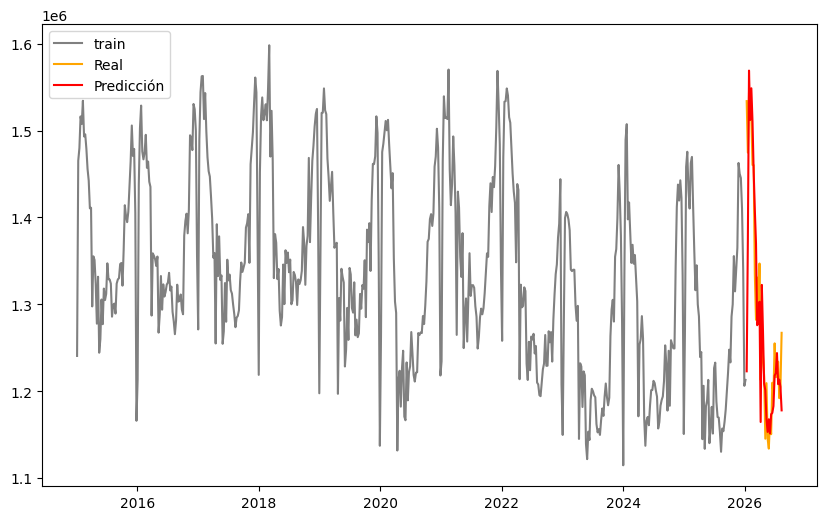

In [39]:
plt.figure(figsize=(10,6))
plt.plot(df_train["ds"], df_train["y"], label="train", color="gray")
plt.plot(df_test["ds"], y_true, label="Real", color="orange")
plt.plot(df_test["ds"], y_preds_neuralprophet, label="Predicción", color="red")
plt.legend()
plt.show()

# Modelo SARIMA
el modelo SARIMA es $SARIMA(1,0,0)(1,0,1)_{52}$

In [40]:
df_data_set_full_sarima = df_data_set_full.copy()
df_train_sarima = df_data_set_full_sarima[df_data_set_full_sarima["Start date"] <= fecha_data_val]
df_test_sarima = df_data_set_full_sarima[df_data_set_full_sarima["Start date"] > fecha_data_val]
print(f"longitud de df_train_sarima: {len(df_train_sarima)}")
print(f"longitud de df_test_sarima: {len(df_test_sarima)}")

longitud de df_train_sarima: 575
longitud de df_test_sarima: 31


In [41]:
# ordenes del modelo 
p_final = 1
d_final = 0
q_final = 0
P_final = 1
D_final = 0
Q_final = 1
s = 52

model_sarima = sm.tsa.statespace.SARIMAX(
    df_train_sarima["value"],
    order = (
        p_final, d_final, q_final
    ),
    seasonal_order=(
        P_final, D_final, Q_final, s
    ),
    enforce_invertibility=True,
    enforce_stationarity=True
)
results_sarima = model_sarima.fit(
    method='lbfgs',
    maxiter=100,
    disp=False
)
results_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                value   No. Observations:                  575
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 52)   Log Likelihood               -7068.287
Date:                              Tue, 15 Sep 2026   AIC                          14144.574
Time:                                      00:25:00   BIC                          14161.992
Sample:                                           0   HQIC                         14151.367
                                              - 575                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9945      0.007    145.902      0.000       0.981       1.008
ar.S.L52       0.8296      0.044     18.695      0.000       0.743       0.917
ma.S.L52      -0.4942      0.070     -7.077      0.000      -0.631      -0.357
sigma2      3.617e+09   5.88e-12   6.15e+20      0.000    3.62e+09    3.62e+09
===================================================================================
Ljung-Box (L1) (Q):                  43.11   Jarque-Bera (JB):               214.28
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.94   Skew:                            -0.25
Prob(H) (two-sided):                  0.66   Kurtosis:                         5.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.36e+37. Standard errors may be unstable.
"""

In [42]:
forecast_sarima_index = df_test_sarima.index
n_forecast = len(df_test_sarima)
forecast_sarima = results_sarima.get_forecast(steps=n_forecast)
forecast_sarima_mean = forecast_sarima.predicted_mean
forecast_sarima_ci = forecast_sarima.conf_int()
forecast_sarima_df = pd.DataFrame({
    "forecast": forecast_sarima_mean.values,
    "lower_ci": forecast_sarima_ci.iloc[:, 0].values,
    "upper_ci": forecast_sarima_ci.iloc[:, 1].values,
})
forecast_sarima_df.head()

,forecast,lower_ci,upper_ci
0,1.313359e+06,1.195487e+06,1.431231e+06
1,1.320563e+06,1.154324e+06,1.486802e+06
2,1.286296e+06,1.083253e+06,1.489338e+06
3,1.279407e+06,1.045595e+06,1.513219e+06
4,1.287983e+06,1.027287e+06,1.548679e+06


In [43]:
# cálculo de errores
# se resetea el índice: df_test_sarima conserva el índice original de df_data_set_full_sarima
# (p. ej. 575..605) mientras que forecast_sarima_df tiene índice por defecto (0..30); al
# restar dos Series de pandas, la alineación es por índice, no por posición, así que sin
# esto casi ningún valor coincide y el resultado queda en NaN (por eso el MAPE daba nan%,
# mientras que MAE/RMSE/sMAPE no se ven afectados porque sklearn/sktime operan por posición)
y_true_sarima = df_test_sarima["value"].reset_index(drop=True)
y_preds_sarima = forecast_sarima_df["forecast"].reset_index(drop=True)


smape_fn = MeanAbsolutePercentageError(symmetric=True)
mae_s  = mean_absolute_error(y_true_sarima, y_preds_sarima)
rmse_s = np.sqrt(mean_squared_error(y_true_sarima, y_preds_sarima))
mape_s = np.mean(np.abs((y_true_sarima - y_preds_sarima) / y_true_sarima))
smape_s = smape_fn(y_true_sarima, y_preds_sarima)

print(f"MAE: {mae_s}")
print(f"RMSE: {rmse_s}")
print(f"MAPE: {mape_s*100:.4f}%")
print(f"sMAPE: {smape_s*100:.4f}%")

MAE: 131934.97997224293
RMSE: 145146.50683997257
MAPE: 9.9586%
sMAPE: 10.5632%


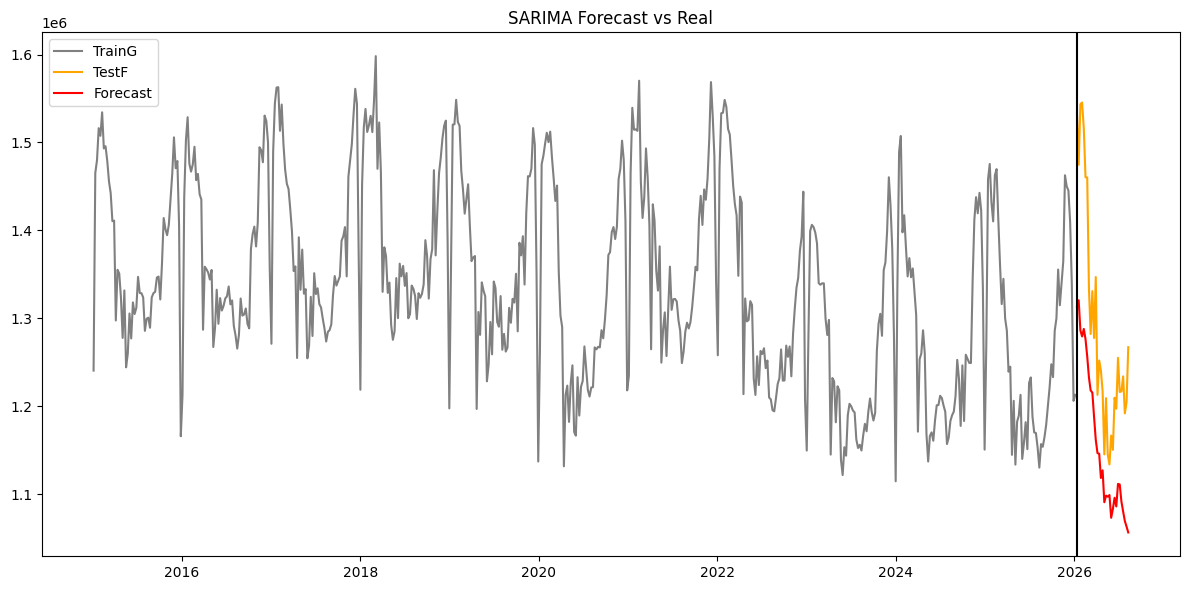

In [44]:
# Ajuste visual
plt.figure(figsize=(12,6))

# Datos reales
plt.plot(df_train_sarima["Start date"], df_train_sarima["value"], label="TrainG", color="gray")
plt.plot(df_test_sarima["Start date"], df_test_sarima["value"], label="TestF", color="orange")

# Predicción
plt.plot(df_test_sarima["Start date"], forecast_sarima_df["forecast"], 
         label="Forecast", color="red")


#linea

plt.axvline(test["Start date"].values[0], color="black")
""" # Intervalos
plt.fill_between(
    test["Start date"],
    forecast_df["lower_ci"],
    forecast_df["upper_ci"],
    color="red",
    alpha=0.2
) """

plt.legend()
plt.title("SARIMA Forecast vs Real")
#plt.grid(True)
plt.tight_layout()
plt.show()

# Predicciones combinadas
se hace el ponderado y se compara con cada modelo individual, y se evaluan las métricas

In [45]:
df_data_set_full.head()

,Start date,value,Serie
0,2015-01-05,1.240580e+06,Entrenamiento
1,2015-01-12,1.465239e+06,Entrenamiento
2,2015-01-19,1.479857e+06,Entrenamiento
3,2015-01-26,1.516270e+06,Entrenamiento
4,2015-02-02,1.507588e+06,Entrenamiento


In [46]:
mask_val = df_data_set_full["Start date"] > fecha_data_val

df_preds = pd.DataFrame({
    "Date": df_data_set_full.loc[mask_val, "Start date"].reset_index(drop=True),
    "original": df_data_set_full.loc[mask_val, "value"].reset_index(drop=True),
    "pred_xgboost": y_preds_xgboost,
    "pred_rnn": y_preds_recurrent,
    "pred_neuralprophet": y_preds_neuralprophet,
    "pred_sarima": y_preds_sarima
})
df_preds.head()


,Date,original,pred_xgboost,pred_rnn,pred_neuralprophet,pred_sarima
0,2026-01-12,1.533895e+06,1384295.375,1332541.250,1222876.625,1.313359e+06
1,2026-01-19,1.474633e+06,1511990.875,1432645.000,1372653.750,1.320563e+06
2,2026-01-26,1.543555e+06,1475741.250,1443738.875,1569024.625,1.286296e+06
3,2026-02-02,1.545466e+06,1467871.375,1407256.250,1512172.875,1.279407e+06
4,2026-02-09,1.515939e+06,1513589.250,1411257.000,1548672.125,1.287983e+06


In [47]:
df_preds["pred_ensemble"] = (
    ensemble_weights["xgboost_preds_v2"] * df_preds["pred_xgboost"] +
    ensemble_weights["neuralprophet_preds"] * df_preds["pred_neuralprophet"] +
    ensemble_weights["rnn_preds"] * df_preds["pred_rnn"] +
    ensemble_weights["SARIMA_preds"] * df_preds["pred_sarima"] 
)
df_preds.head()

,Date,original,pred_xgboost,pred_rnn,pred_neuralprophet,pred_sarima,pred_ensemble
0,2026-01-12,1.533895e+06,1384295.375,1332541.250,1222876.625,1.313359e+06,1.316886e+06
1,2026-01-19,1.474633e+06,1511990.875,1432645.000,1372653.750,1.320563e+06,1.418843e+06
2,2026-01-26,1.543555e+06,1475741.250,1443738.875,1569024.625,1.286296e+06,1.452676e+06
3,2026-02-02,1.545466e+06,1467871.375,1407256.250,1512172.875,1.279407e+06,1.425329e+06
4,2026-02-09,1.515939e+06,1513589.250,1411257.000,1548672.125,1.287983e+06,1.450288e+06


In [48]:
# comparación metricas preds ensemble
# métricas de error

y_true = df_preds["original"].values
y_pred_ensemble = df_preds["pred_ensemble"].values
smape_fn = MeanAbsolutePercentageError(symmetric=True)
mae_ens  = mean_absolute_error(y_true, y_pred_ensemble)
rmse_ens = np.sqrt(mean_squared_error(y_true, y_pred_ensemble))
mape_ens = mean_absolute_percentage_error(y_true, y_pred_ensemble)
smape_ens = smape_fn(y_true, y_pred_ensemble)

print(f"MAE: {mae_ens}")
print(f"RMSE: {rmse_ens}")
print(f"MAPE: {mape_ens*100:.4f}%")
print(f"sMAPE: {smape_ens*100:.4f}%")

MAE: 48125.74486158936
RMSE: 64727.47522601903
MAPE: 3.5773%
sMAPE: 3.6794%


In [49]:
# tabla comparativa de metricas de error por modelo y ensemble
df_metrics = pd.DataFrame({
    "Modelo": ["XGBoost", "RNN", "NeuralProphet", "SARIMA", "Ensemble"],
    "MAE": [mae_val_xgboost, mae_rnn, mae_np, mae_s, mae_ens],
    "RMSE": [rmse_val_xgboost, rmse_rnn, rmse_np, rmse_s, rmse_ens],
    "MAPE (%)": [mape_val_xgboost * 100, mape_rnn * 100, mape_np * 100, mape_s * 100, mape_ens * 100],
    "sMAPE (%)": [smape_val_xgboost * 100, smape_rnn * 100, smape_np * 100, smape_s * 100, smape_ens * 100],
}).set_index("Modelo").round(4)

df_metrics

,MAE,RMSE,MAPE (%),sMAPE (%)
Modelo,,,,
XGBoost,38236.7546,48904.5901,2.9031,2.9173
RNN,53911.8883,70140.1552,4.0381,4.1461
NeuralProphet,45584.1700,71461.4930,3.4055,3.4815
SARIMA,131934.9800,145146.5068,9.9586,10.5632
Ensemble,48125.7449,64727.4752,3.5773,3.6794


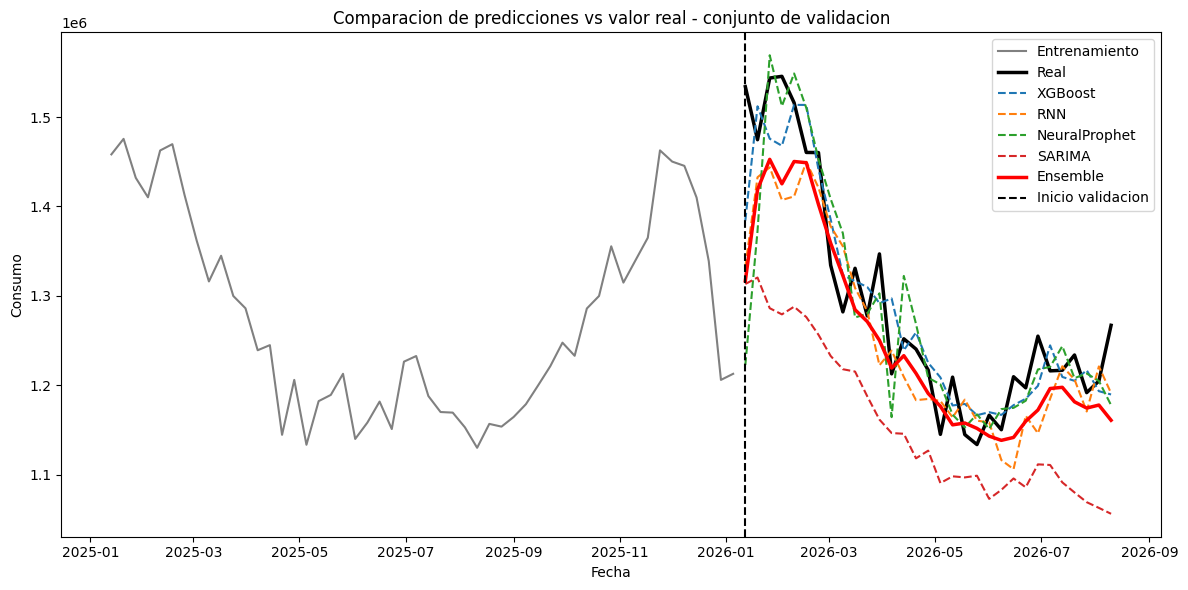

In [50]:
# grafica comparativa de ajuste - todos los modelos vs valor real
# se incluye un pedazo de la serie de entrenamiento (ultimas 52 semanas antes del corte)
# como contexto, y una linea vertical punteada que marca donde empieza la validacion
train_tail = df_data_set_full[
    df_data_set_full["Start date"] <= fecha_data_val
].tail(52)

plt.figure(figsize=(12, 6))

plt.plot(train_tail["Start date"], train_tail["value"], label="Entrenamiento", color="gray")
plt.plot(df_preds["Date"], df_preds["original"], label="Real", color="black", linewidth=2.5)
plt.plot(df_preds["Date"], df_preds["pred_xgboost"], label="XGBoost", linestyle="--")
plt.plot(df_preds["Date"], df_preds["pred_rnn"], label="RNN", linestyle="--")
plt.plot(df_preds["Date"], df_preds["pred_neuralprophet"], label="NeuralProphet", linestyle="--")
plt.plot(df_preds["Date"], df_preds["pred_sarima"], label="SARIMA", linestyle="--")
plt.plot(df_preds["Date"], df_preds["pred_ensemble"], label="Ensemble", color="red", linewidth=2.5)

plt.axvline(
    df_preds["Date"].iloc[0],
    color="black",
    linestyle="--",
    label="Inicio validacion"
)

plt.title("Comparacion de predicciones vs valor real - conjunto de validacion")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()
plt.tight_layout()
plt.show()